In [16]:
import pandas as pd


test_df = pd.read_csv('spacecraft_test_preprocessed.csv')
train_df = pd.read_csv('spacecraft_train_preprocessed.csv')

In [17]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

# Fit and transform the 'race' column to convert categories to numbers
train_df['race'] = label_encoder.fit_transform(train_df['race'])


In [18]:
# train 5 models randomforest, svm, xgboost, catboost, and decision tree

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier

models = [
    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1),
    # SVC(),
    XGBClassifier(),
    CatBoostClassifier(),
    DecisionTreeClassifier()
]

# split train
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

X = train_df.drop('race', axis=1)
y = train_df['race']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

feature_importance_list = []

for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    feature_importance = model.feature_importances_ if hasattr(model, 'feature_importances_') else None
    feature_importance_list.append(feature_importance)
    print(f'{model.__class__.__name__} f1 score: {f1}')

RandomForestClassifier f1 score: 0.7810123705521916
XGBClassifier f1 score: 0.8737506724195179
Learning rate set to 0.080274
0:	learn: 1.0563863	total: 6.46ms	remaining: 6.45s
1:	learn: 1.0249610	total: 12.5ms	remaining: 6.25s
2:	learn: 0.9911872	total: 17.9ms	remaining: 5.94s
3:	learn: 0.9628511	total: 24.2ms	remaining: 6.03s
4:	learn: 0.9408236	total: 30ms	remaining: 5.96s
5:	learn: 0.9160191	total: 36.8ms	remaining: 6.1s
6:	learn: 0.8943020	total: 42.4ms	remaining: 6.02s
7:	learn: 0.8771401	total: 55.4ms	remaining: 6.87s
8:	learn: 0.8595281	total: 63.9ms	remaining: 7.04s
9:	learn: 0.8432853	total: 70.1ms	remaining: 6.94s
10:	learn: 0.8270912	total: 76.6ms	remaining: 6.89s
11:	learn: 0.8116539	total: 82.3ms	remaining: 6.77s
12:	learn: 0.7951397	total: 87.3ms	remaining: 6.63s
13:	learn: 0.7835400	total: 92ms	remaining: 6.48s
14:	learn: 0.7694143	total: 97.1ms	remaining: 6.37s
15:	learn: 0.7585324	total: 102ms	remaining: 6.24s
16:	learn: 0.7446965	total: 106ms	remaining: 6.15s
17:	lear

In [19]:
#catboost need to be /100
feature_importance_list[2] = feature_importance_list[2] / 100

In [14]:
feature_importance_list[2]

array([3.37956879e-07, 2.00416482e-06, 0.00000000e+00, 6.09730041e-06,
       2.71203914e-05, 8.51398630e-06, 5.97268159e-06, 1.89847355e-06,
       3.05887795e-06, 2.62478085e-06, 4.06462126e-06, 1.83863890e-06,
       4.15389717e-06, 2.86740175e-06, 6.77413223e-06, 2.03872270e-06,
       5.55952745e-06, 2.58371650e-06, 1.85535068e-06, 3.77473121e-06,
       2.03572422e-06, 3.75621449e-06, 1.06870768e-06])

In [15]:
feature_importance_list

[array([0.0039958 , 0.01887629, 0.00080329, 0.03691251, 0.2380392 ,
        0.07333133, 0.09143131, 0.00667915, 0.04734576, 0.01882663,
        0.03817765, 0.04011097, 0.09418696, 0.07169093, 0.03379162,
        0.02213543, 0.02247769, 0.0109938 , 0.01115526, 0.03631682,
        0.02835125, 0.02108876, 0.03328159]),
 array([0.0206134 , 0.03658138, 0.01868479, 0.03682786, 0.20687741,
        0.04418147, 0.06436317, 0.01551383, 0.05074432, 0.03945907,
        0.05337842, 0.02091911, 0.04015373, 0.03307466, 0.05906735,
        0.02528015, 0.04414644, 0.02028827, 0.02081531, 0.05741205,
        0.03080918, 0.03413482, 0.02667391], dtype=float32),
 array([ 1.73757566,  3.08653581,  0.9316053 ,  4.52046908, 14.14599621,
         8.5756922 ,  6.07782255,  2.73914119,  6.40769213,  4.55732888,
         3.86667528,  4.42438629,  5.83083856,  5.68276443,  6.42165857,
         1.34488619,  5.23847064,  1.24895141,  0.93859381,  3.616695  ,
         3.11812757,  3.49487201,  1.99322124]),
 array([

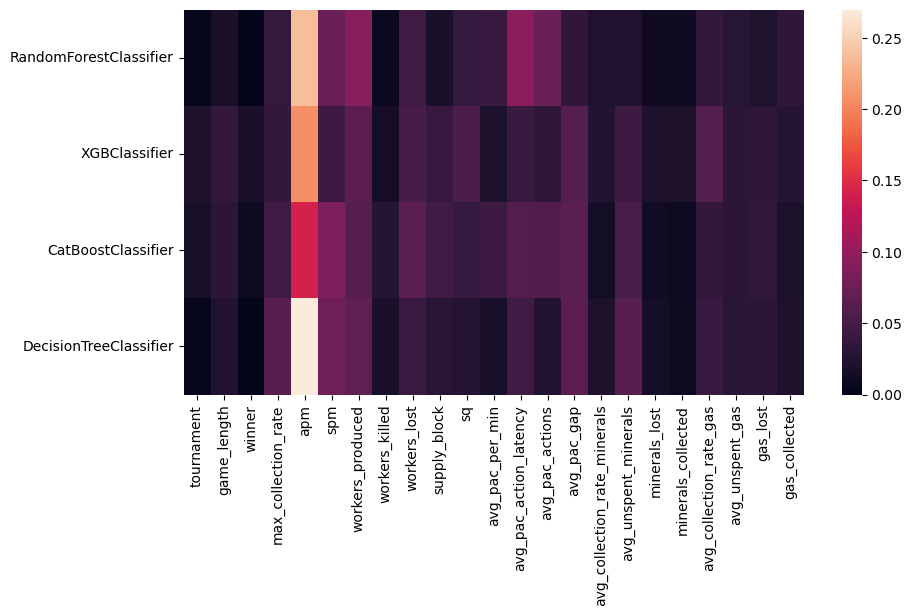

In [24]:
# make heatmap using feature importance

import matplotlib.pyplot as plt
import seaborn as sns

feature_importance_df = pd.DataFrame(feature_importance_list, columns=X.columns, index=[model.__class__.__name__ for model in models])
plt.figure(figsize=(10, 5))
sns.heatmap(feature_importance_df, annot=False)
plt.show()

In [28]:
# get shapley values

import shap

shap.initjs()

for model in models:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    

In [29]:
shap_values

array([[[-8.06913228e-03,  1.12491378e-02, -3.18000550e-03],
        [ 7.66637330e-04, -2.22387033e-03,  1.45723300e-03],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 9.95022453e-03, -7.14333794e-03, -2.80688659e-03],
        [ 5.90940579e-03,  6.17919987e-03, -1.20886057e-02],
        [ 1.36328878e-02, -8.28587570e-03, -5.34701205e-03]],

       [[ 1.26128441e-03, -1.01918210e-03, -2.42102302e-04],
        [ 3.29814020e-04, -1.99200330e-01,  1.98870516e-01],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 1.87127157e-03,  8.16437170e-03, -1.00356433e-02],
        [-4.75894919e-02,  2.36790703e-02,  2.39104216e-02],
        [-1.83667940e-03,  4.59154736e-03, -2.75486796e-03]],

       [[ 1.34660716e-03, -9.56768501e-04, -3.89838655e-04],
        [ 8.00929081e-04, -9.81610489e-02,  9.73601198e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [-5.03894128e-03,  8.22600190e-03,